In [1]:
import os
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
from cv_tools.utils import COCOEvalPlus
from matplotlib.ticker import MultipleLocator
import os

import plot_utils as pu
from cv_tools import utils
import config as C

%load_ext autoreload
%autoreload 1
%aimport config
%aimport cv_tools.utils
%aimport plot_utils

/Users/s2785075/miniconda3/envs/cv_tools/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
_ = C.setup_plotting(rc=C.RC_PAPER)

N_FOLDS = 3
CCF = True
results_dir = os.path.join(C.RESULTS_DIR, 'ENHANCE_final_revisions')
data_dir = C.DATA_DIR

# Preprocessing speed (measured externally)

In [3]:
PPS_SPEEDS = pd.read_csv(os.path.join(results_dir, 'PPS_SPEED.csv'), index_col=0)['milliseconds']
PPS_SPEEDS

adjust_sigmoid                       24.7
DCP                                  92.8
adjust_gamma_down                     5.4
FUnIE-GAN                             1.9
adjust_gamma_up                       5.4
NONE                                  0.0
unsharp_mask                         27.8
CAP                                 469.8
adjust_log                           22.4
autocontrast                         13.7
ace                                2256.2
CLAHE                                 2.8
ARCR                                203.6
grey_world                            7.9
MLLE                                408.9
resized_MSRCR_15_80_250_new           9.8
resized_MSRCR_15_80_250_fk         3844.0
resized_MSRCR_15_80_250_new_CPU     295.1
Name: milliseconds, dtype: float64

# Domain-based splitting results tables

In [4]:
res_dir = 'FINAL_GROUPS'
results_df = pd.read_csv(os.path.join(results_dir, f'{res_dir}.csv'))
results_df = results_df.loc[results_df['pps'].isnull() | results_df['pps'].isin(C.ALL_PPS)]
wide_df = {}
for model in ['dt2', 'yolo8']:
    print('\n----------\n', model, '\n----------\n')
    dfs = []
    for dataset in C.MAIN_DATASETS:
        df = results_df.loc[(results_df['model'] == model) & (results_df['dataset'] == dataset)].sort_values('mAP')
        df[f'rank_{dataset}'] = range(len(df), 0, -1)
        df = df.rename({'mAP': f'mAP_{dataset}', 'std': f'std_{dataset}'}, axis=1)
        df.loc[df['pps'].isnull(), 'pps'] = 'NONE'
        df = df.set_index(['pps'])[[f'rank_{dataset}', f'mAP_{dataset}', f'std_{dataset}']]
        assert df.index.is_unique
        dfs.append(df)
    wide_df[model] = pd.concat(dfs, axis=1).sort_values('rank_DeepFish', ascending=False)
    table = pu.pps_df_to_latex(wide_df[model], placeholder=PPS_SPEEDS.to_dict())
    print('\n'.join(table))
    display(wide_df[model])
    wide_df[model].to_csv(os.path.join(results_dir, f'wide.{res_dir}.{model}.csv'))


----------
 dt2 
----------

Adjust sigmoid &   24.7 & $41.3 \pm 4.2$ & 16 & $46.8 \pm 2.5$ & 15 & $40.5 \pm 2.2$ & 15\\
    Gamma down &    5.4 & $45.2 \pm 3.0$ & 15 & $51.3 \pm 2.5$ & 9  & $43.2 \pm 1.7$ & 7 \\
     FUnIE-GAN &    1.9 & $46.1 \pm 3.7$ & 14 & $44.8 \pm 0.5$ & 16 & $42.9 \pm 1.6$ & 10\\
      Gamma up &    5.4 & $46.4 \pm 2.5$ & 13 & $50.3 \pm 3.3$ & 11 & $42.5 \pm 0.4$ & 12\\
           DCP &   92.8 & $46.6 \pm 4.0$ & 12 & $49.9 \pm 3.8$ & 12 & $42.4 \pm 2.1$ & 13\\
 No processing &    0.0 & $46.8 \pm 5.5$ & 11 & $52.6 \pm 2.1$ & 8  & $43.1 \pm 2.3$ & 8 \\
  Unsharp mask &   27.8 & $47.0 \pm 6.1$ & 10 & $50.5 \pm 2.3$ & 10 & $42.6 \pm 1.4$ & 11\\
           CAP &  469.8 & $47.2 \pm 1.2$ & 9  & $47.6 \pm 5.2$ & 14 & $39.1 \pm 2.2$ & 16\\
    Adjust log &   22.4 & $48.1 \pm 4.7$ & 8  & $47.6 \pm 1.8$ & 13 & $43.1 \pm 2.5$ & 9 \\
 Auto-contrast &   13.7 & $48.8 \pm 7.2$ & 7  & $56.9 \pm 2.1$ & 4  & $\textit{46.2} \pm \textit{1.9}$ & \textit{2}\\
           ACE & 2256.2 

,rank_DeepFish,mAP_DeepFish,std_DeepFish,rank_GLOW_low_visibility_estuaries,mAP_GLOW_low_visibility_estuaries,std_GLOW_low_visibility_estuaries,rank_Jellytoring,mAP_Jellytoring,std_Jellytoring
pps,,,,,,,,,
adjust_sigmoid,16,0.413345,0.041947,15,0.468287,0.024549,15,0.404827,0.022425
adjust_gamma_down,15,0.452319,0.029787,9,0.513179,0.024872,7,0.432331,0.017197
FUnIE-GAN,14,0.461266,0.037080,16,0.448103,0.005156,10,0.429415,0.016393
adjust_gamma_up,13,0.464464,0.024720,11,0.503475,0.033022,12,0.424819,0.004319
DCP,12,0.466290,0.039949,12,0.498690,0.037728,13,0.424392,0.021041
NONE,11,0.468151,0.054874,8,0.526182,0.021451,8,0.430812,0.022553
unsharp_mask,10,0.469915,0.060674,10,0.504777,0.023464,11,0.426228,0.013939
CAP,9,0.471537,0.012290,14,0.475638,0.052043,16,0.390955,0.021590
adjust_log,8,0.481267,0.047060,13,0.475955,0.017553,9,0.430753,0.024870



----------
 yolo8 
----------

     FUnIE-GAN &    1.9 & $39.0 \pm 8.5$ & 16 & $45.7 \pm 0.8$ & 14 & $39.7 \pm 2.6$ & 13\\
  Unsharp mask &   27.8 & $39.2 \pm 2.9$ & 15 & $48.0 \pm 2.0$ & 9  & $41.5 \pm 4.0$ & 11\\
    Gamma down &    5.4 & $39.7 \pm 7.7$ & 14 & $43.7 \pm 1.5$ & 16 & $42.3 \pm 2.4$ & 10\\
Adjust sigmoid &   24.7 & $40.4 \pm 4.1$ & 13 & $45.2 \pm 1.4$ & 15 & $37.8 \pm 1.9$ & 16\\
    Adjust log &   22.4 & $40.6 \pm 4.5$ & 12 & $46.6 \pm 2.5$ & 13 & $42.6 \pm 2.4$ & 7 \\
 No processing &    0.0 & $41.6 \pm 4.3$ & 11 & $46.9 \pm 1.8$ & 12 & $40.3 \pm 2.0$ & 12\\
 Auto-contrast &   13.7 & $44.5 \pm 6.0$ & 10 & $\textit{54.1} \pm \textit{1.7}$ & \textit{2} & $\textit{45.6} \pm \textit{2.0}$ & \textit{2}\\
      Gamma up &    5.4 & $45.2 \pm 2.2$ & 9  & $46.9 \pm 2.5$ & 11 & $42.7 \pm 1.4$ & 6 \\
           ACE & 2256.2 & $45.9 \pm 6.1$ & 8  & $52.8 \pm 1.3$ & 5  & $43.3 \pm 3.1$ & 5 \\
         CLAHE &    2.8 & $48.1 \pm 7.6$ & 7  & $48.4 \pm 3.4$ & 8  & $42.4 \pm 1.5$ & 9

,rank_DeepFish,mAP_DeepFish,std_DeepFish,rank_GLOW_low_visibility_estuaries,mAP_GLOW_low_visibility_estuaries,std_GLOW_low_visibility_estuaries,rank_Jellytoring,mAP_Jellytoring,std_Jellytoring
pps,,,,,,,,,
FUnIE-GAN,16,0.390132,0.085378,14,0.457440,0.008144,13,0.397498,0.026490
unsharp_mask,15,0.391837,0.029132,9,0.479753,0.020308,11,0.415079,0.039755
adjust_gamma_down,14,0.397449,0.076943,16,0.437104,0.014950,10,0.423175,0.023991
adjust_sigmoid,13,0.403855,0.041489,15,0.452416,0.013930,16,0.377968,0.018568
adjust_log,12,0.406325,0.044634,13,0.465799,0.024869,7,0.425788,0.024486
NONE,11,0.416163,0.042668,12,0.468726,0.018377,12,0.403464,0.020139
autocontrast,10,0.444916,0.059665,2,0.540780,0.017338,2,0.455932,0.019654
adjust_gamma_up,9,0.451570,0.021935,11,0.469152,0.024713,6,0.426539,0.014384
ace,8,0.458630,0.060502,5,0.528462,0.013274,5,0.433051,0.030571


# Domain-based splitting improvements (delta mAP)

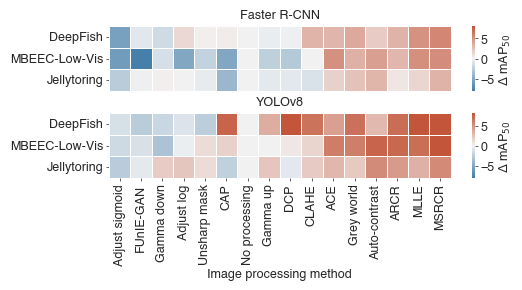

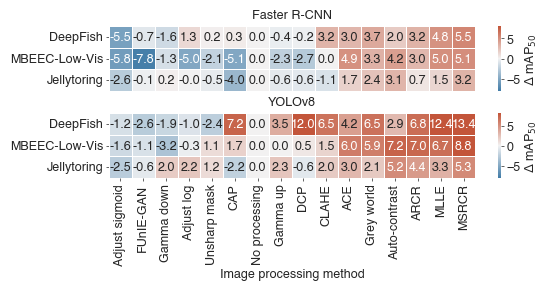

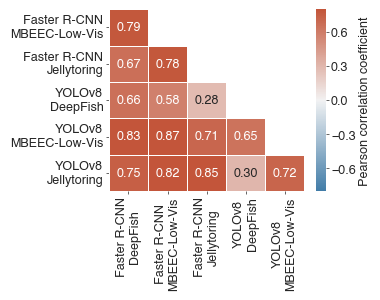

In [5]:
res_dir = 'FINAL_GROUPS'
wide_df = {model : pd.read_csv(os.path.join(results_dir, f'wide.{res_dir}.{model}.csv')).set_index('pps')
           for model in ['dt2', 'yolo8']}

df = {}
for model in wide_df:
    df[model] = wide_df[model][[f'mAP_{d}' for d in C.MAIN_DATASETS]] * 100
    df[model] -= df[model].loc['NONE']
    df[model] = df[model].rename(lambda x: x.replace('mAP_', ''), axis=1)

for ANNOT in [False, True]:
    fig, axs = plt.subplots(2, 1, figsize=((15 if ANNOT else 14) * C.CM, (5 if ANNOT else 5) * C.CM))
    plt.subplots_adjust(hspace=0.35)
    mean_delta_mAP = pd.concat([df[model] for model in wide_df], axis=1).mean(axis=1).sort_values(ascending=True)
    for i, (ax, model) in enumerate(zip(axs, wide_df)):
        plot_df = df[model].loc[mean_delta_mAP.index]
        plot_df = plot_df.rename(lambda x: C.RENAME_PPS.get(x, x), axis=0)
        plot_df = plot_df.rename(lambda x: C.RENAME_DATASETS.get(x, x), axis=1)
        ax = sns.heatmap(
            plot_df.T, cmap=C.DIV_CMAP, vmin=-8, vmax=8, center=0, linewidths=0.5,
            cbar_kws={'label': 'Δ mAP$_{50}$'}, annot=ANNOT, fmt='.1f', ax=ax
        )
        if i < 1:
            ax.axes.get_xaxis().set_ticks([])
        ax.set_xlabel('Image processing method' if i == 1 else None)
        ax.set_title(C.MODEL_NAMES[model])
    utils.savefig(os.path.join(results_dir, 'figures', f'delta_mAP.heatmaps{".annotated" if ANNOT else ""}'))
    plt.show()

df = {}
for model in wide_df:
    df[model] = wide_df[model][[f'mAP_{d}' for d in C.MAIN_DATASETS]] * 100
    df[model] = df[model].rename(lambda x: x.replace('mAP_', ''), axis=1)
    
corr_df = pd.concat([df[model].drop('NONE').rename(lambda d: f'{C.MODEL_NAMES[model]}\n{C.RENAME_DATASETS.get(d, d)}', axis=1) for model in df], axis=1).corr()
corr_df.values[np.triu_indices_from(corr_df)] = np.nan
corr_df = corr_df.loc[~corr_df.isnull().all(axis=1), ~corr_df.isnull().all(axis=0)]
fig, ax = plt.subplots(1, 1, figsize=(8 * C.CM, 6 * C.CM))
sns.heatmap(
    corr_df, cmap=C.DIV_CMAP, vmin=-0.8, vmax=0.8, center=0, linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation coefficient'}, annot=True, fmt='.2f', ax=ax
)
ax.collections[0].colorbar.set_ticks([-0.6, -0.3, 0, 0.3, 0.6])
utils.savefig(os.path.join(results_dir, 'figures', f'mAP_cross_correlation'))
plt.show()

# Cross-method and cross-dataset mAP correlation

In [6]:
for model in ['dt2', 'yolo8']:
    for i, (_, x) in enumerate(df[model].T.iterrows()):
        for _, y in df[model].T.iloc[i + 1:].iterrows():
            print(scipy.stats.pearsonr(x, y))
    display(df[model].corr())
    
for i, (_, x) in enumerate(df['dt2'].T.iterrows()):
    for _, y in df['yolo8'].T.iterrows():
        print(scipy.stats.pearsonr(x, y))
display(df['yolo8'].corrwith(df['dt2']))

PearsonRResult(statistic=0.7772458989988832, pvalue=0.0003955172423196783)
PearsonRResult(statistic=0.667079591362015, pvalue=0.0047604214286533835)
PearsonRResult(statistic=0.7822840412249937, pvalue=0.00034190991663284325)


,DeepFish,GLOW_low_visibility_estuaries,Jellytoring
DeepFish,1.000000,0.777246,0.667080
GLOW_low_visibility_estuaries,0.777246,1.000000,0.782284
Jellytoring,0.667080,0.782284,1.000000


PearsonRResult(statistic=0.6597253989943662, pvalue=0.0054250571566754925)
PearsonRResult(statistic=0.33147195292583337, pvalue=0.20978239446261626)
PearsonRResult(statistic=0.7259119386300401, pvalue=0.0014544473804195212)


,DeepFish,GLOW_low_visibility_estuaries,Jellytoring
DeepFish,1.000000,0.659725,0.331472
GLOW_low_visibility_estuaries,0.659725,1.000000,0.725912
Jellytoring,0.331472,0.725912,1.000000


PearsonRResult(statistic=0.9110447374992022, pvalue=9.316929309574146e-07)
PearsonRResult(statistic=0.6413354939715125, pvalue=0.0074149886549005695)
PearsonRResult(statistic=0.3451206797593353, pvalue=0.19047801356985383)
PearsonRResult(statistic=0.779512597614303, pvalue=0.0003706000747752165)
PearsonRResult(statistic=0.5201605723717632, pvalue=0.03887947797885991)
PearsonRResult(statistic=0.08710380212809239, pvalue=0.7483902130649946)
PearsonRResult(statistic=0.627940637554507, pvalue=0.009199163438893496)
PearsonRResult(statistic=0.3729461156253044, pvalue=0.1548178718191869)
PearsonRResult(statistic=0.1204641460734939, pvalue=0.6567578329009846)


DeepFish                         0.663485
GLOW_low_visibility_estuaries    0.854729
Jellytoring                      0.842277
dtype: float64

# Speed and accuracy correlation

,delta_mAP,speed
adjust_sigmoid,-3.213345,24.7
FUnIE-GAN,-2.160726,1.9
adjust_gamma_down,-0.965670,5.4
adjust_log,-0.460171,22.4
unsharp_mask,-0.431785,27.8
CAP,-0.347247,469.8
NONE,0.000000,0.0
adjust_gamma_up,0.442011,5.4
DCP,1.387418,92.8
CLAHE,2.023651,2.8


3844.0


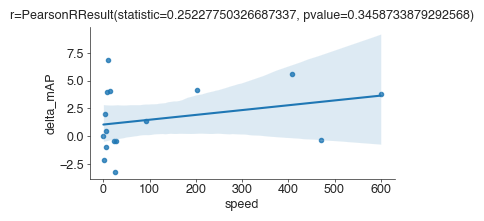

In [8]:
# speed and mAP
speed_df = pd.concat((mean_delta_mAP.rename('delta_mAP'), PPS_SPEEDS.rename('speed')), axis=1)
display(speed_df)

fig, ax = plt.subplots(1, 1, figsize=(10 * C.CM, 5 * C.CM))
print(speed_df['speed'].max())
speed_df = speed_df.loc[~speed_df.isnull().any(axis=1)]
ax = sns.regplot(x=speed_df['speed'].clip(upper=600), y=speed_df['delta_mAP'])
ax.set_title(f"r={scipy.stats.pearsonr(speed_df['speed'], speed_df['delta_mAP'])}")
sns.despine()

# Image quality measures and mAP

In [9]:
data_df = {}
for dataset in C.MAIN_DATASETS:
    print(dataset)
    data_df[dataset] = []
    for pps in ['resized_MSRCR', 'resized_MSRCR_15_80_250_new', 'resized_MSRCR_15_80_250_fk']:
        df = pd.concat([
            pd.read_csv(os.path.join(data_dir, 'resources_jsons', dataset, f'{eval_func}.{pps if pps != "NONE" else "images"}.csv'), index_col=['filename', 'transform'])
            for eval_func in ['UIQMw15', 'SSIMw10', 'PSNR']
            if not (pps == 'NONE' and not eval_func.startswith('UIQM'))
        ], axis=1)
        data_df[dataset].append((df[['UIQM', 'UIConM', 'UICM', 'UISM'] + (['SSIM', 'PSNR'] if pps != 'NONE' else [])]).mean().rename(pps))
    data_df[dataset] = pd.concat(data_df[dataset], axis=1).T
    display(data_df[dataset])

DeepFish


,UIQM,UIConM,UICM,UISM,SSIM,PSNR
resized_MSRCR,2.759817,0.319362,1.381100,5.347287,0.824156,18.161294
resized_MSRCR_15_80_250_new,2.829862,0.334011,1.882496,5.359243,0.830716,18.982447
resized_MSRCR_15_80_250_fk,2.877545,0.334023,1.896691,5.519222,0.848439,18.930869


GLOW_low_visibility_estuaries


,UIQM,UIConM,UICM,UISM,SSIM,PSNR
resized_MSRCR,1.064586,0.234190,0.728143,0.700140,0.902269,17.474398
resized_MSRCR_15_80_250_new,1.199108,0.268198,1.373555,0.682303,0.909756,18.036172
resized_MSRCR_15_80_250_fk,1.220390,0.271673,1.350787,0.714479,0.912869,17.865884


Jellytoring


,UIQM,UIConM,UICM,UISM,SSIM,PSNR
resized_MSRCR,1.618955,0.291875,1.463545,1.808817,0.804553,16.659374
resized_MSRCR_15_80_250_new,1.689940,0.310289,2.215193,1.754475,0.831813,18.683215
resized_MSRCR_15_80_250_fk,1.685417,0.310140,2.228183,1.739712,0.833250,18.673860


,NMSS,UIQM,UIConM,UICM,UISM,NIQE,SSIM,PSNR
mAP_DeepFish,0.5827 *,0.3861,0.0517,-0.1463,0.4257,-0.1582,-0.4375,-0.1926
mAP_GLOW_low_visibility_estuaries,0.8173 ***,0.0044,0.117,0.4188,-0.1839,0.0578,0.0593,-0.342
mAP_Jellytoring,0.6232 **,0.5506 *,0.7392 **,-0.3739,0.0878,-0.1018,0.2995,0.1169


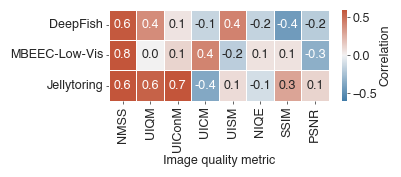

DeepFish


NMSS      -0.578650
UIQM       1.859866
UIConM     0.166299
UICM       1.882496
UISM       2.774841
NIQE       2.970487
SSIM       0.713390
PSNR      16.024973
Name: min, dtype: float64

NMSS      -0.091095
UIQM       3.014299
UIConM     0.334011
UICM       6.710066
UISM       6.364878
NIQE       5.841141
SSIM       0.981428
PSNR      38.511170
Name: max, dtype: float64

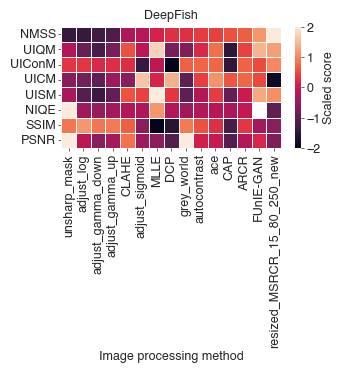

GLOW_low_visibility_estuaries


NMSS      -0.717455
UIQM       0.634584
UIConM     0.121442
UICM       0.379882
UISM       0.235037
NIQE       3.841044
SSIM       0.647355
PSNR      13.660410
Name: min, dtype: float64

NMSS       0.148661
UIQM       2.130981
UIConM     0.327319
UICM       4.544372
UISM       3.231614
NIQE       5.258951
SSIM       0.992416
PSNR      43.664014
Name: max, dtype: float64

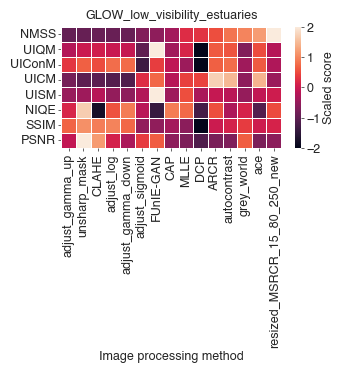

Jellytoring


NMSS       0.294619
UIQM       0.935983
UIConM     0.094923
UICM       2.215193
UISM       1.170116
NIQE       4.074856
SSIM       0.742043
PSNR      18.392577
Name: min, dtype: float64

NMSS       0.455503
UIQM       2.066934
UIConM     0.310289
UICM       6.447553
UISM       3.275281
NIQE       5.793438
SSIM       0.976721
PSNR      36.962648
Name: max, dtype: float64

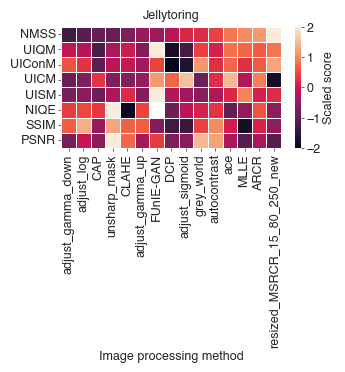

In [10]:
NMSS_COL = 'S2' # 'S5' 'S10'
res_dir = 'FINAL_GROUPS'
wide_df = {model : pd.read_csv(os.path.join(results_dir, f'wide.{res_dir}.{model}.csv')).set_index('pps')
           for model in ['dt2', 'yolo8']}

data_df = {}
for dataset in C.MAIN_DATASETS:
    data_df[dataset] = []
    for pps in ['NONE'] + C.ALL_PPS:
        df = pd.concat([
            pd.read_csv(os.path.join(data_dir, 'resources_jsons', dataset, f'{eval_func}.{pps if pps != "NONE" else "images"}.csv'), index_col=['filename', 'transform'])
            for eval_func in ['UIQMw15', 'SSIMw10', 'PSNR', 'NIQE']
            if not (pps == 'NONE' and (eval_func.startswith('SSIMw10') or eval_func.startswith('PSNR')))
        ], axis=1)
        data_df[dataset].append((df[['UIQM', 'UIConM', 'UICM', 'UISM', 'NIQE'] + (['SSIM', 'PSNR'] if pps != 'NONE' else [])]).mean().rename(pps))
    data_df[dataset] = pd.concat(data_df[dataset], axis=1).T
    silh_df = pd.read_csv(f'../data/resources_jsons/{dataset}/silhouette.csv', index_col=0)[NMSS_COL].rename('NMSS')
    data_df[dataset] = pd.concat((-1 * silh_df, data_df[dataset]), axis=1)

AVERAGE_MODELS = True

if AVERAGE_MODELS:
    img_qual_corr_df = []
    img_qual_pval_df = []
    for dataset in data_df:
        _df = pd.concat([wide_df[model][f'mAP_{dataset}'] for model in wide_df], axis=1).mean(axis=1).rename(f'mAP_{dataset}')
        _df = pd.concat((_df, data_df[dataset]), axis=1)
        img_qual_corr_df.append(_df.corr(method='pearson')[f'mAP_{dataset}'])
        img_qual_pval_df.append((_df.corr(method=lambda x, y: scipy.stats.pearsonr(x, y)[1]) - np.eye(*img_qual_corr_df[-1].shape))[f'mAP_{dataset}'])
    img_qual_corr_df = pd.concat(img_qual_corr_df, axis=1).drop([f'mAP_{dataset}' for dataset in C.MAIN_DATASETS])
    img_qual_pval_df = pd.concat(img_qual_pval_df, axis=1).drop([f'mAP_{dataset}' for dataset in C.MAIN_DATASETS])
    # display(img_qual_corr_df)
    # display(img_qual_pval_df)
    p = img_qual_pval_df.applymap(lambda x: ''.join(['*' for t in [.05, .01, .001] if x<=t]))
    display((img_qual_corr_df.round(4).astype(str) + ' ' + p).T)
else:
    img_qual_corr_df, img_qual_pval_df = {}, {}
    for model in wide_df:
        print(model)
        img_qual_corr_df[model] = []
        img_qual_pval_df[model] = []
        for dataset in data_df:
            _df = pd.concat((wide_df[model][f'mAP_{dataset}'], data_df[dataset]), axis=1)
            img_qual_corr_df[model].append(_df.corr(method='pearson')[f'mAP_{dataset}'])
            img_qual_pval_df[model].append((_df.corr(method=lambda x, y: scipy.stats.pearsonr(x, y)[1]) - np.eye(*img_qual_corr_df[model][-1].shape))[f'mAP_{dataset}'])
        img_qual_corr_df[model] = pd.concat(img_qual_corr_df[model], axis=1).drop([f'mAP_{dataset}' for dataset in C.MAIN_DATASETS])
        img_qual_pval_df[model] = pd.concat(img_qual_pval_df[model], axis=1).drop([f'mAP_{dataset}' for dataset in C.MAIN_DATASETS])
        # display(img_qual_corr_df[model])
        # display(img_qual_pval_df[model])
        p = img_qual_pval_df[model].applymap(lambda x: ''.join(['*' for t in [.05, .01, .001] if x<=t]))
        display((img_qual_corr_df[model].round(4).astype(str) + ' ' + p).T)
    
ANNOT = True
if AVERAGE_MODELS:
    fig, ax = plt.subplots(1, 1, figsize=((9 if ANNOT else 5.5) * C.CM, (3 if ANNOT else 2) * C.CM))
    plot_df = img_qual_corr_df.copy()
    plot_df = plot_df.rename(lambda x: C.RENAME_DATASETS.get(x.replace('mAP_', ''), x.replace('mAP_', '')), axis=1)
    ax = sns.heatmap(
        plot_df.T, cmap=C.DIV_CMAP, vmin=-0.6, vmax=0.6, center=0, linewidths=0.5,
        cbar_kws={'label': 'Correlation'}, annot=ANNOT, fmt='.1f', ax=ax
    )
    ax.set_xlabel('Image quality metric')
    utils.savefig(os.path.join(results_dir, 'figures', f'qual_scores.heatmaps{".annotated" if ANNOT else ""}'))
    plt.show()
else:
    fig, axs = plt.subplots(2, 1, figsize=((9 if ANNOT else 5.5) * C.CM, (6 if ANNOT else 5) * C.CM))
    plt.subplots_adjust(hspace=0.35)
    # mean_delta_mAP = pd.concat([df[model] for model in wide_df], axis=1).mean(axis=1).sort_values(ascending=True)
    for i, (ax, model) in enumerate(zip(axs, wide_df)):
        plot_df = img_qual_corr_df[model].copy()
        plot_df = plot_df.rename(lambda x: C.RENAME_DATASETS.get(x.replace('mAP_', ''), x.replace('mAP_', '')), axis=1)
        ax = sns.heatmap(
            plot_df.T, cmap=C.DIV_CMAP, vmin=-0.6, vmax=0.6, center=0, linewidths=0.5,
            cbar_kws={'label': 'Correlation'}, annot=ANNOT, fmt='.1f', ax=ax
        )
        if i < 1:
            ax.axes.get_xaxis().set_ticks([])
        ax.set_xlabel('Image quality metric' if i == 1 else None)
        ax.set_title(C.MODEL_NAMES[model])
    utils.savefig(os.path.join(results_dir, 'figures', f'qual_scores.heatmaps{".annotated" if ANNOT else ""}'))
    plt.show()
    
for dataset in data_df:
    fig, ax = plt.subplots(1, 1, figsize=(9 * C.CM, 4 * C.CM))
    plot_df = data_df[dataset].loc[data_df[dataset].index != 'NONE'].sort_values('NMSS')
    print(dataset)
    display(plot_df.min().rename('min'))
    display(plot_df.max().rename('max'))
    plot_df = (plot_df - plot_df.mean()) / plot_df.std()
    ax = sns.heatmap(
        plot_df.T, cmap=None, vmin=-2, vmax=2, center=None, linewidths=0.5,
        cbar_kws={'label': 'Scaled score'}, annot=False, fmt='.1f', ax=ax
    )
    ax.set_xlabel('Image processing method')
    ax.set_title(dataset)
    utils.savefig(os.path.join(results_dir, 'figures', f'qual_scores.{dataset}.heatmaps'))
    plt.show()

# PR curves

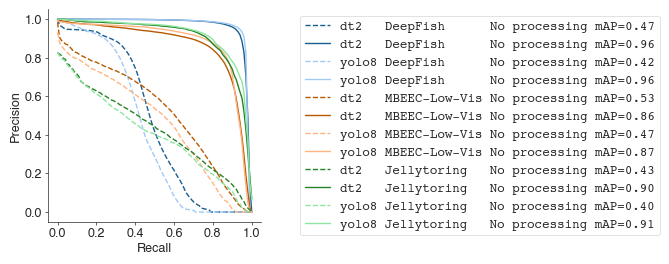

In [11]:
fig, ax = plt.subplots(1, 1, figsize=C.PR_CURVE_SIZE, squeeze=True)
ax, results = pu.pps_pr_curves(
    pickle_prefix=[os.path.join(results_dir, 'pickles', 'FINAL_GROUPS'), os.path.join(results_dir, 'pickles', 'FINAL_NO_GROUPS')],
    augms=[None, None], linestyles=['--', '-'], models=['dt2', 'yolo8'],
    eval_type=['Groups', 'NoGroups'],
    datasets=C.MAIN_DATASETS, model_select='best', split='test', ax=ax
)
utils.savefig(os.path.join(results_dir, 'figures', f'{res_dir}.Groups_vs_NoGroups'))

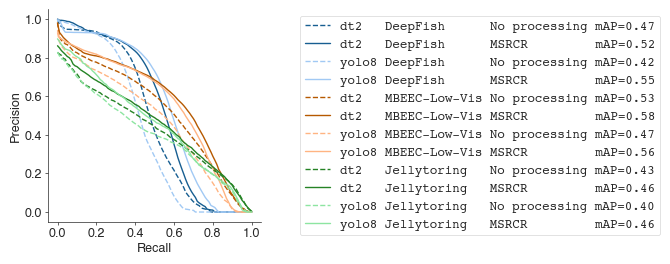

In [12]:
res_dir = 'FINAL_GROUPS'
pickle_prefix = os.path.join(results_dir, 'pickles', res_dir)
fig, ax = plt.subplots(1, 1, figsize=C.PR_CURVE_SIZE, squeeze=True)
ax, results = pu.pps_pr_curves(pickle_prefix=pickle_prefix, augms=[None, 'resized_MSRCR_15_80_250_new'], linestyles=['--', '-'], models=['dt2', 'yolo8'], datasets=C.MAIN_DATASETS, model_select='best', split='test', eval_type='Groups', ax=ax)
utils.savefig(os.path.join(results_dir, 'figures', f'{res_dir}.None_vs_MSRCR'))

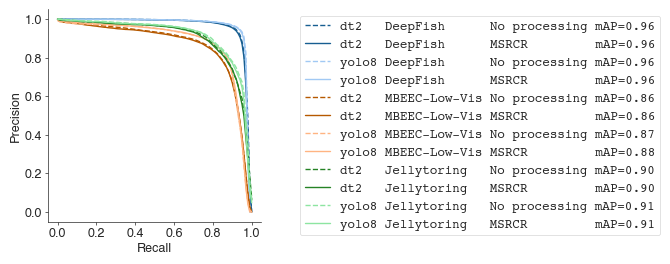

In [13]:
res_dir = 'FINAL_NO_GROUPS'
pickle_prefix = os.path.join(results_dir, 'pickles', res_dir)
fig, ax = plt.subplots(1, 1, figsize=C.PR_CURVE_SIZE, squeeze=True)
ax, results = pu.pps_pr_curves(pickle_prefix=pickle_prefix, augms=[None, 'resized_MSRCR_15_80_250_new'], linestyles=['--', '-'], models=['dt2', 'yolo8'], datasets=C.MAIN_DATASETS, model_select='best', split='test', eval_type='NoGroups', ax=ax)
utils.savefig(os.path.join(results_dir, 'figures', f'{res_dir}.None_vs_MSRCR'))

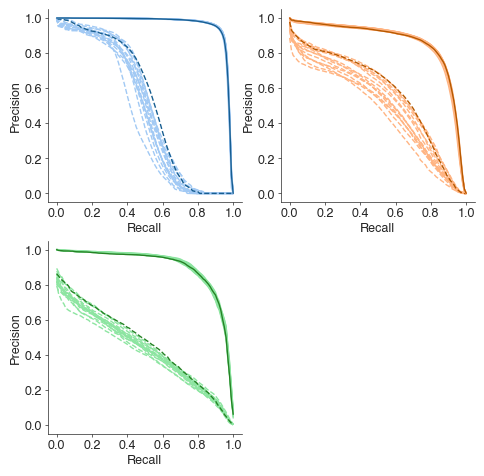

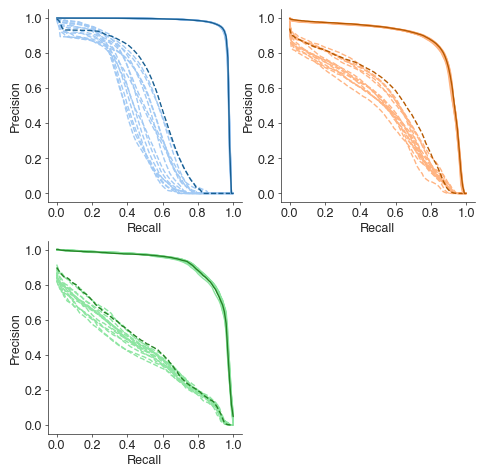

In [14]:
res_dir = 'FINAL_GROUPS'
n_curves = len(C.ALL_PPS)
for model in ['dt2', 'yolo8']:
    fig, axs = plt.subplots(2, 2, figsize=(C.PR_CURVE_SIZE[0] * 2, C.PR_CURVE_SIZE[1] * 2), squeeze=True)
    for i, dataset in enumerate(C.MAIN_DATASETS):
        ax = axs[i // 2, i % 2]
        ax, results = pu.pps_pr_curves(
            pickle_prefix=([os.path.join(results_dir, 'pickles', 'FINAL_GROUPS')] * n_curves) +
                          ([os.path.join(results_dir, 'pickles', 'FINAL_NO_GROUPS')] * n_curves),
            augms=C.ALL_PPS + C.ALL_PPS,
            eval_type=['Groups'] * n_curves + (['NoGroups'] * n_curves),
            linestyles=['--'] * n_curves + (['-'] * n_curves),
            palettes=[C.LIGHT[i:]],
            highlight='resized_MSRCR_15_80_250_new', highlight_palettes=[C.DARK[i:]],
            models=[model], datasets=[dataset],
            model_select='best', split='test', ax=ax
        )
        ax.legend().set_visible(False)
    axs[1, 1].axis('off')
    utils.savefig(os.path.join(results_dir, 'figures', f'all_pps.Groups.NoGroups.{model}'))

# S-UODAC - domain-based splitting evaluation table

In [15]:
res_dir = 'FINAL_S-UODAC'
results_df = pd.read_csv(os.path.join(results_dir, f'{res_dir}.csv'))
results_df

,model,dataset,pps,eval,mAP,std,mAPs,s0_AP,s1_AP,s2_AP,s3_AP
0,dt2,S-UODAC,NaN,NoValRepro,0.536890,0.015359,"[0.5155597208285356, 0.5511077306495968, 0.544...",0.765657,0.414242,0.503105,0.464558
1,dt2,S-UODAC,resized_MSRCR,NoValRepro,0.644925,0.013045,"[0.627867293747724, 0.6595397734335382, 0.6473...",0.803511,0.633998,0.562151,0.580039
2,dt2,S-UODAC,resized_MSRCR_15_80_250_new,NoValRepro,0.630734,0.010732,"[0.6168358436198506, 0.642965069833928, 0.6324...",0.809395,0.627984,0.562262,0.523294
3,yolo3,S-UODAC,NaN,NoValRepro,0.381904,0.042253,"[0.41038236874741574, 0.41315768583534335, 0.3...",0.686658,0.310962,0.293312,0.236682
4,yolo3,S-UODAC,resized_MSRCR,NoValRepro,0.617186,0.004226,"[0.6155659381007338, 0.6229771883492863, 0.613...",0.779981,0.580774,0.543334,0.564653
5,yolo3,S-UODAC,resized_MSRCR_15_80_250_new,NoValRepro,0.612921,0.004094,"[0.6086024042033539, 0.6184207962990117, 0.611...",0.780988,0.610864,0.534572,0.525260


In [16]:
res_dir = 'FINAL_NO_GROUPS'
results_df = pd.read_csv(os.path.join(results_dir, f'{res_dir}.csv'))
for model in ['dt2', 'yolo8']:
    print('\n----------\n', model, '\n----------\n')
    dfs = []
    for dataset in C.MAIN_DATASETS:
        df = results_df.loc[(results_df['model'] == model) & (results_df['dataset'] == dataset)].sort_values('mAP')
        df[f'rank_{dataset}'] = range(len(df), 0, -1)
        df = df.rename({'mAP': f'mAP_{dataset}', 'std': f'std_{dataset}'}, axis=1)
        df = df.set_index(['pps'])[[f'rank_{dataset}', f'mAP_{dataset}', f'std_{dataset}']]
        assert df.index.is_unique
        dfs.append(df)
    df = pd.concat(dfs, axis=1).sort_values('rank_DeepFish', ascending=False)
    table = pu.pps_df_to_latex(df, placeholder='', decorate_bold=True, decorate_ital=False)
    print('\n'.join(table))
    print('\nLARGEST IMPROVEMENT TO "No processing" (%):')
    display(100 * (df - df.loc[np.nan]).max().loc[['mAP_DeepFish', 'mAP_GLOW_low_visibility_estuaries', 'mAP_Jellytoring']])
    print('')
    display(df)


----------
 dt2 
----------

     FUnIE-GAN & $95.6 \pm 0.1$ & 16 & $84.9 \pm 0.7$ & 16 & $89.8 \pm 0.1$ & 13\\
           CAP & $95.9 \pm 0.1$ & 15 & $85.3 \pm 0.1$ & 13 & $89.7 \pm 0.1$ & 15\\
         MSRCR & $96.0 \pm 0.1$ & 14 & $85.8 \pm 0.1$ & 11 & $89.7 \pm 0.2$ & 16\\
Adjust sigmoid & $96.0 \pm 0.1$ & 13 & $85.9 \pm 0.1$ & 8  & $89.8 \pm 0.4$ & 14\\
    Gamma down & $96.1 \pm 0.1$ & 12 & $85.5 \pm 0.5$ & 12 & $90.5 \pm 0.3$ & 3 \\
         CLAHE & $96.1 \pm 0.1$ & 11 & $85.3 \pm 0.2$ & 14 & $90.3 \pm 0.1$ & 7 \\
           DCP & $96.1 \pm 0.2$ & 10 & $85.2 \pm 0.3$ & 15 & $90.1 \pm 0.3$ & 9 \\
    Adjust log & $96.1 \pm 0.1$ & 9  & $85.9 \pm 0.2$ & 7  & $90.3 \pm 0.3$ & 6 \\
  Unsharp mask & $96.1 \pm 0.1$ & 8  & $85.9 \pm 0.5$ & 9  & $90.0 \pm 0.4$ & 10\\
 Auto-contrast & $96.1 \pm 0.1$ & 7  & $86.2 \pm 0.3$ & 3  & $90.4 \pm 0.4$ & 5 \\
          ARCR & $96.1 \pm 0.1$ & 6  & $\textbf{86.3} \pm \textbf{0.2}$ & \textbf{1} & $90.0 \pm 0.3$ & 12\\
           ACE & $96.2 \pm 0.1$

mAP_DeepFish                         0.010481
mAP_GLOW_low_visibility_estuaries    0.098228
mAP_Jellytoring                      0.490432
dtype: float64

,rank_DeepFish,mAP_DeepFish,std_DeepFish,rank_GLOW_low_visibility_estuaries,mAP_GLOW_low_visibility_estuaries,std_GLOW_low_visibility_estuaries,rank_Jellytoring,mAP_Jellytoring,std_Jellytoring
pps,,,,,,,,,
FUnIE-GAN,16,0.956113,0.000740,16,0.848602,0.006551,13,0.897773,0.001465
CAP,15,0.958941,0.001284,13,0.853028,0.001367,15,0.897485,0.000714
resized_MSRCR_15_80_250_new,14,0.959838,0.000927,11,0.857640,0.001131,16,0.897467,0.001922
adjust_sigmoid,13,0.960267,0.000952,8,0.859185,0.001185,14,0.897512,0.004161
adjust_gamma_down,12,0.960511,0.000977,12,0.855290,0.004965,3,0.904859,0.002666
CLAHE,11,0.960729,0.000551,14,0.852881,0.002311,7,0.903063,0.000788
DCP,10,0.960752,0.001523,15,0.851809,0.002660,9,0.901441,0.002956
adjust_log,9,0.960937,0.001419,7,0.859245,0.002130,6,0.903126,0.003160
unsharp_mask,8,0.961071,0.001353,9,0.859180,0.004741,10,0.900486,0.003566



----------
 yolo8 
----------

           CAP & $95.9 \pm 0.1$ & 16 & $87.0 \pm 0.3$ & 14 & $90.2 \pm 0.2$ & 16\\
     FUnIE-GAN & $96.1 \pm 0.0$ & 15 & $86.7 \pm 0.2$ & 15 & $90.9 \pm 0.2$ & 11\\
          MLLE & $96.1 \pm 0.0$ & 14 & $87.5 \pm 0.3$ & 5  & $90.9 \pm 0.1$ & 12\\
  Unsharp mask & $96.1 \pm 0.1$ & 13 & $87.3 \pm 0.4$ & 12 & $90.8 \pm 0.1$ & 13\\
Adjust sigmoid & $96.2 \pm 0.1$ & 12 & $87.4 \pm 0.2$ & 10 & $90.5 \pm 0.4$ & 15\\
           DCP & $96.2 \pm 0.0$ & 11 & $86.6 \pm 0.3$ & 16 & $91.0 \pm 0.4$ & 10\\
         MSRCR & $96.2 \pm 0.1$ & 10 & $87.6 \pm 0.3$ & 2  & $90.8 \pm 0.1$ & 14\\
         CLAHE & $96.3 \pm 0.0$ & 9  & $87.4 \pm 0.2$ & 8  & $91.2 \pm 0.1$ & 5 \\
    Grey world & $96.3 \pm 0.0$ & 8  & $87.6 \pm 0.2$ & 3  & $\textbf{91.6} \pm \textbf{0.3}$ & \textbf{1}\\
    Gamma down & $96.3 \pm 0.0$ & 7  & $87.5 \pm 0.2$ & 4  & $91.2 \pm 0.3$ & 8 \\
    Adjust log & $96.3 \pm 0.1$ & 6  & $87.2 \pm 0.3$ & 13 & $91.3 \pm 0.2$ & 4 \\
           ACE & $96.3 \pm 0.

mAP_DeepFish                         0.000000
mAP_GLOW_low_visibility_estuaries    0.317088
mAP_Jellytoring                      0.173394
dtype: float64

,rank_DeepFish,mAP_DeepFish,std_DeepFish,rank_GLOW_low_visibility_estuaries,mAP_GLOW_low_visibility_estuaries,std_GLOW_low_visibility_estuaries,rank_Jellytoring,mAP_Jellytoring,std_Jellytoring
pps,,,,,,,,,
CAP,16,0.958959,0.000971,14,0.869993,0.003387,16,0.901947,0.001774
FUnIE-GAN,15,0.960561,0.000486,15,0.866530,0.002009,11,0.909283,0.001795
MLLE,14,0.961123,0.000375,5,0.874965,0.003336,12,0.909043,0.001452
unsharp_mask,13,0.961143,0.000941,12,0.872777,0.004383,13,0.908232,0.001362
adjust_sigmoid,12,0.961698,0.001027,10,0.873721,0.002412,15,0.905185,0.003942
DCP,11,0.962034,0.000485,16,0.866458,0.002827,10,0.910270,0.003967
resized_MSRCR_15_80_250_new,10,0.962167,0.000962,2,0.875969,0.002957,14,0.907775,0.000946
CLAHE,9,0.962579,0.000422,8,0.874317,0.002371,5,0.912387,0.001298
grey_world,8,0.963193,0.000243,3,0.875759,0.001785,1,0.915827,0.002817


# NMS thresholds 0.5 vs 0.7 (DeepFish, domain-based splitting evaluation)

In [17]:
res_dir = 'FINAL_GROUPS'
results_df = pd.read_csv(os.path.join(results_dir, f'{res_dir}.csv'))
results_df.loc[results_df['pps'].isnull(), 'pps'] = 'NMS70'
results_df = results_df.loc[(results_df['dataset'] == 'DeepFish') & results_df['pps'].isin(['NMS70', 'NMS50'])]
for model in ['dt2', 'yolo8']:
    x = results_df.loc[results_df['model'] == model].set_index('pps')
    print(model, 'NMS50 - NMS70', (x.loc['NMS50', 'mAP'] - x.loc['NMS70', 'mAP']) * 100)
results_df

dt2 NMS50 - NMS70 0.7374033793999923
yolo8 NMS50 - NMS70 0.5772497022941747


,model,dataset,pps,eval,mAP,std,mAPs
0,dt2,DeepFish,NMS70,Groups,0.468151,0.054874,"[0.41930351518172104, 0.5447968724647027, 0.44..."
1,dt2,DeepFish,NMS50,Groups,0.475525,0.045539,"[0.44846496988276124, 0.5396655405530153, 0.43..."
55,yolo8,DeepFish,NMS70,Groups,0.416163,0.042668,"[0.37502239170112134, 0.4749622854077081, 0.39..."
56,yolo8,DeepFish,NMS50,Groups,0.421935,0.041715,"[0.3803938398798184, 0.47898100624945045, 0.40..."


# MLLE combined with MSRCR

In [18]:
res_dir = 'MLLE_MSRCR_combi'
results_df = pd.read_csv(os.path.join(results_dir, f'{res_dir}.csv'))
display(results_df)
MLLE_MSRCR_combi = results_df.loc[(results_df['pps'] == 'resized_MSRCR_MLLE') & (results_df['dataset'] == 'DeepFish')].set_index('model')['mAP']
MSRCR_MLLE_combi = results_df.loc[(results_df['pps'] == 'MLLE_resized_MSRCR') & (results_df['dataset'] == 'DeepFish')].set_index('model')['mAP']

res_dir = 'FINAL_GROUPS'
results_df = pd.read_csv(os.path.join(results_dir, f'{res_dir}.csv'))
MSRCR = results_df.loc[(results_df['pps'] == 'resized_MSRCR') & (results_df['dataset'] == 'DeepFish')].set_index('model')['mAP']

display((MLLE_MSRCR_combi - MSRCR) * 100)
display((MSRCR_MLLE_combi - MSRCR) * 100)

,model,dataset,pps,eval,mAP,std,mAPs
0,yolo8,DeepFish,MLLE_resized_MSRCR,Groups,0.485876,0.026191,"[0.46421049413715937, 0.5227259785165099, 0.47..."
1,yolo8,DeepFish,resized_MSRCR_MLLE,Groups,0.537132,0.061568,"[0.5730054276468635, 0.5879019452692945, 0.450..."
2,dt2,DeepFish,MLLE_resized_MSRCR,Groups,0.487162,0.042317,"[0.44463703694020584, 0.5448917615573152, 0.47..."
3,dt2,DeepFish,resized_MSRCR_MLLE,Groups,0.528898,0.021822,"[0.559222268058264, 0.5186969427629908, 0.5087..."


model
dt2     -0.391543
yolo8   -1.771084
Name: mAP, dtype: float64

model
dt2     -4.565174
yolo8   -6.896688
Name: mAP, dtype: float64

# Training dataset subsampling

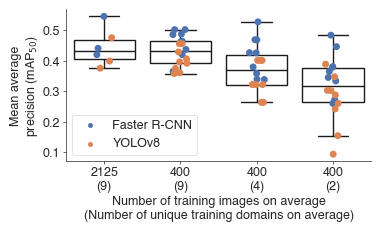

dt2


pps
NONE             0.000000
ssT400          -1.037800
ssT400.ssG50    -5.397552
ssT400.ssG25   -10.581873
Name: mAP, dtype: float64


yolo8


pps
NONE             0.000000
ssT400          -1.357150
ssT400.ssG50    -8.782605
ssT400.ssG25   -15.225750
Name: mAP, dtype: float64

In [20]:
# load the results
res_dir = 'FINAL_GROUPS'
results_df = pd.read_csv(os.path.join(results_dir, f'{res_dir}.csv'))
results_df = results_df.loc[pd.isnull(results_df['pps']) & (results_df['dataset'] == 'DeepFish')]
results_df['pps'] = 'NONE'

res_dir = 'SUBSAMPLE'
results_df = pd.concat([
    results_df,
    pd.read_csv(os.path.join(results_dir, f'{res_dir}.csv'))
])

# determine how many domains was used for training
imgs_group_sizes = {}
eval_type = 'Groups'
dataset = 'DeepFish'
for model in ['yolo8', 'dt2']:
    for res_dir, exps in [
        ('FINAL_GROUPS', [None]),
        ('SUBSAMPLE', ['.ssT400.x1', '.ssT400.x2', '.ssT400.x3']),
        ('SUBSAMPLE', ['.ssT400.ssG50.x1', '.ssT400.ssG50.x2', '.ssT400.ssG50.x3']),
        ('SUBSAMPLE', ['.ssT400.ssG25.x1', '.ssT400.ssG25.x2', '.ssT400.ssG25.x3']),
        # ('SUBSAMPLE', ['.ssT1000.x1', '.ssT1000.x2', '.ssT1000.x3']),
        # ('SUBSAMPLE', ['.ssT1000.ssG50.x1', '.ssT1000.ssG50.x2', '.ssT1000.ssG50.x3']),
    ]:
        n_groups, n_imgs = [], []
        for exp in exps:
            for seed in [2, 7, 9]:
                for fold in [0, 1, 2]:
                    fn = os.path.join(results_dir, res_dir, f'{model}.{dataset}.CV.{eval_type}{"" if exp is None else exp}.seed{seed}', 'datasets', f'annotations.seed{seed}.fold{fold}.train.json.gz')
                    imgs = utils.read_json(fn, verbose=False)['images']
                    groups = utils.get_filename_groups(imgs)
                    n_imgs.append(len(imgs))
                    n_groups.append(len(set(groups)))
        name = '.'.join(exp.split('.')[1:-1]) if exp is not None else 'NONE'
        n_groups = round(np.mean(n_groups))
        n_imgs = round(np.mean(n_imgs))
        if name in imgs_group_sizes:
            assert imgs_group_sizes[name] == (n_imgs, n_groups)
        else:
            imgs_group_sizes[name] = (n_imgs, n_groups)
            

# prepare DF for plotting using results for every seed
df = []
for _, row in results_df.loc[(results_df['dataset'] == 'DeepFish') & (results_df['eval'] == 'Groups')].iterrows():
    for mAP in eval(row['mAPs']):
        df.append([row['model'], row['pps'], row['mAP'], mAP])
df = pd.DataFrame.from_records(df, columns=['model', 'pps', 'avg_mAP', 'mAP'])
df['model'] = df['model'].transform(lambda x: C.MODEL_NAMES[x])
df = df.loc[df['pps'].str.contains('^ssT400|^NONE$')].sort_values(['model'])
_rename = {pps: imgs_group_sizes[pps] for pps in df['pps'].unique()}
df['pps'] = df['pps'].transform(lambda x: f'{_rename[x][0]}\n({_rename[x][1]})')

# plot
dodge = False
fig, ax = plt.subplots(1, 1, figsize=(10 * C.CM, 5 * C.CM))
ax = sns.boxplot(data=df, x='pps', y='mAP', hue='model' if dodge else None, dodge=dodge,
            fliersize=0, ax=ax, **pu.black_boxplot_kwargs())
ax = sns.stripplot(data=df, x='pps', y='mAP', hue='model', dodge=dodge,
                   palette='deep', ax=ax)
ax.set_ylabel('Mean average\nprecision (mAP$_{50}$)')
ax.set_xlabel('Number of training images on average\n(Number of unique training domains on average)')
ax.legend(title=None)
sns.despine()
utils.savefig(os.path.join(results_dir, 'figures', 'subsample'))
plt.show()

for model in ['dt2', 'yolo8']:
    print(model)
    x = results_df.loc[(results_df['model'] == model) & (results_df['dataset'] == 'DeepFish')  & ~results_df['pps'].str.contains('T1000')].groupby('pps')['mAP'].mean()
    display(((x - x.loc['NONE']) * 100).sort_values(ascending=False))
    print('')

DeepFish
Training set size dt2 PearsonRResult(statistic=0.13702847614113706, pvalue=0.7251790427761665) N = 9
Training domains dt2 PearsonRResult(statistic=0.11191463048130457, pvalue=0.7743756249777749) N = 9
Training set size yolo8 PearsonRResult(statistic=0.08610102968153267, pvalue=0.8256764231155624) N = 9
Training domains yolo8 PearsonRResult(statistic=-0.1589139490199747, pvalue=0.6829989170209002) N = 9
GLOW_low_visibility_estuaries
Training set size dt2 PearsonRResult(statistic=0.18425931740350684, pvalue=0.6350887108795357) N = 9
Training domains dt2 PearsonRResult(statistic=0.16746436045644417, pvalue=0.6667170206105093) N = 9
Training set size yolo8 PearsonRResult(statistic=0.32179429374190827, pvalue=0.39841253268310045) N = 9
Training domains yolo8 PearsonRResult(statistic=0.4403822541390497, pvalue=0.23549515464203055) N = 9
Jellytoring
Training set size dt2 PearsonRResult(statistic=-0.0486768712990623, pvalue=0.9010318852275367) N = 9
Training domains dt2 PearsonRResult

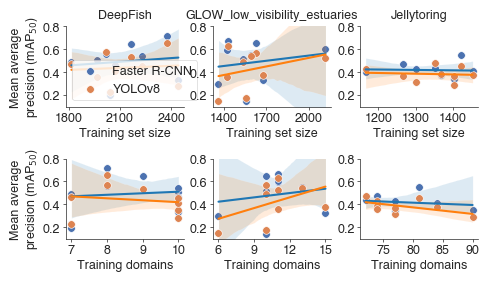

In [31]:
eval_type = 'Groups'
fig, axs = plt.subplots(2, 3, figsize=(13.5 * C.CM, 7 * C.CM))
plt.subplots_adjust(hspace=0.65, wspace=0.25)

n_imgs, n_domains, mAPs = {}, {}, {}
for i, dataset in enumerate(C.MAIN_DATASETS):
    print(dataset)
    n_imgs[dataset], n_domains[dataset], mAPs[dataset] = {}, {}, {}
    for c, (model, marker, ls) in enumerate(zip(['dt2', 'yolo8'], ['o', 'o'], ['-', '-'])):
        n_imgs[dataset][model], n_domains[dataset][model], mAPs[dataset][model] = [], [], []
        for seed in C.ALL_SEEDS[dataset]:
            results = pu.get_results(model=model, dataset=dataset, eval_type=eval_type, augm=None, model_select='best', split='test', concat=False, pickle_prefix=os.path.join(results_dir, 'pickles', 'FINAL_GROUPS'))
            for fold in range(len(results[seed])):
                _, fn = results[seed][fold].gt_fn.split('FINAL_GROUPS/')
                fn = os.path.join(results_dir, 'FINAL_GROUPS', fn.replace('.test.json', '.train.json'))
                d = utils.read_json(fn, verbose=False)
                domains = utils.get_filename_groups(d['images'])
                mAP = results[seed][fold].precision.mean(axis=0)
                n_imgs[dataset][model].append(len(d['images']))
                n_domains[dataset][model].append(len(set(domains)))
                mAPs[dataset][model].append(mAP.mean())

        
        for row, (n_data, xlabel) in enumerate([
            (n_imgs, 'Training set size'),
            (n_domains, 'Training domains')
        ]):
            print(xlabel, model, scipy.stats.pearsonr(n_data[dataset][model], mAPs[dataset][model]), 'N =', len(n_data[dataset][model]))
            ax = axs[row, i]
            ax = sns.regplot(x=n_data[dataset][model], y=mAPs[dataset][model], marker='.', n_boot=1000, ci=95, line_kws=dict(ls=ls), scatter_kws=dict(alpha=0), ax=ax)
            ax = sns.scatterplot(x=n_data[dataset][model], y=mAPs[dataset][model], marker=marker, s=30, ax=ax,
                                 color=sns.color_palette('deep')[c], label=C.MODEL_NAMES[model])
            ax.set_ylim((0.1, 0.8))
            ax.set_ylabel('Mean average\nprecision (mAP$_{50}$)' if i == 0 else None)
            ax.set_xlabel(xlabel)
            ax.set_title(dataset if row == 0 else None)
            ax.set_yticks([0.2, 0.4, 0.6, 0.8])
            ax.legend().set_visible(False)
    sns.despine()
    
axs[0, 0].legend().set_visible(True)

axs[0, 0].set_xticks([1800, 2100, 2400])
axs[0, 1].set_xticks([1400, 1700, 2000])
axs[0, 2].set_xticks([1200, 1300, 1400])

axs[1, 0].set_xticks([7, 8, 9, 10])
axs[1, 1].set_xticks([6, 9, 12, 15])
axs[1, 2].set_xticks([75, 80, 85, 90])

utils.savefig(os.path.join(results_dir, 'figures', 'N_vs_mAP50'))
plt.show()

# print('Correlation across 3 datasets, 3 folds, 3 replicates:')
# for model in ['dt2', 'yolo8']:
#     print(model, scipy.stats.pearsonr([x for d in n_imgs for x in n_imgs[d][model]], [x for d in n_imgs for x in mAPs[d][model]]), 'N =', len([x for d in n_imgs for x in n_imgs[d][model]]))

In [32]:
for d in n_imgs:
    for m in n_imgs[d]:
        ni = n_imgs[d][m]
        nd = n_domains[d][m]
        print(d, m, 'IMAGES', 'min:', np.min(ni), 'max:', np.max(ni), 'mean:', int(round(np.mean(ni))), 'DOMAINS', 'min:', np.min(nd), 'max:', np.max(nd), 'mean:', int(round(np.mean(nd))))

DeepFish dt2 IMAGES min: 1815 max: 2441 mean: 2125 DOMAINS min: 7 max: 10 mean: 9
DeepFish yolo8 IMAGES min: 1815 max: 2441 mean: 2125 DOMAINS min: 7 max: 10 mean: 9
GLOW_low_visibility_estuaries dt2 IMAGES min: 1360 max: 2118 mean: 1589 DOMAINS min: 6 max: 15 mean: 11
GLOW_low_visibility_estuaries yolo8 IMAGES min: 1360 max: 2118 mean: 1589 DOMAINS min: 6 max: 15 mean: 11
Jellytoring dt2 IMAGES min: 1166 max: 1452 mean: 1348 DOMAINS min: 72 max: 90 mean: 78
Jellytoring yolo8 IMAGES min: 1166 max: 1452 mean: 1348 DOMAINS min: 72 max: 90 mean: 78


# Comparing MSRCR configurations

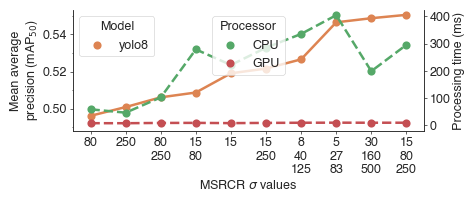

In [33]:
res_dir = 'SIGMAS_NEW'
results_df = pd.read_csv(os.path.join(results_dir, f'{res_dir}.csv'))
assert results_df['pps'].str.endswith('_new').all()
assert results_df['pps'].str.startswith('resized_').all()
results_df['pps'] = results_df['pps'].str.replace('^resized_', '', regex=True).str.replace('_new$', '', regex=True)
results_df = results_df.set_index('pps').sort_values('mAP')
assert results_df.index.is_unique

speed_df = pd.read_csv(os.path.join(results_dir, f'MSRCR_SPEED.csv'))
speed_df = speed_df.loc[~speed_df['windows'].str.contains('169]')]
speed_df = speed_df.set_index('name').loc[results_df.index].reset_index()
speed_df = speed_df.loc[speed_df['processor'].isin(['MacM2', 'A100GPU'])]
speed_df['processor'] = speed_df['processor'].transform(lambda x: 'CPU' if x == 'MacM2' else x.replace('A100', ''))
speed_df['sigmas'] = [s[1:-1].replace(', ', '\n') for s in speed_df['sigmas']]
results_df = results_df.reset_index()

fig, ax = plt.subplots(1, 1, figsize=(11.5 * C.CM, 4 * C.CM))
ax = sns.pointplot(data=results_df, x='pps', y='mAP', hue='model', errorbar='sd',
                   # hue_order=[C.MODEL_NAMES['dt2'], C.MODEL_NAMES['yolo8']],
                   palette=np.asarray(sns.color_palette('deep'))[[1]], ax=ax)
# ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('Mean average\nprecision (mAP$_{50}$)')
ax.set_xlabel('MSRCR $\sigma$ values')
ax.set_ylim((ax.get_ylim()[0]-0.0055, ax.get_ylim()[1]))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))
ax.legend(title='Model', loc='upper left')
ax = ax.twinx()

ax = sns.pointplot(data=speed_df, x='sigmas', y='time', hue='processor', linestyles='--',
                   palette=np.asarray(sns.color_palette('deep'))[[2, 3]], ax=ax)
# ax.tick_params(axis='x', rotation=90)
ax.set_xlabel('MSRCR $\sigma$ values')
ax.set_ylabel('Processing time (ms)')
ax.set_ylim((ax.get_ylim()[0]-9, ax.get_ylim()[1]))
ax.set_yticks([0, 100, 200, 300, 400])
ax.legend(title='Processor', loc='upper center')
sns.despine(right=False)

utils.savefig(os.path.join(results_dir, 'figures', 'compare_sigmas.mAP_and_speed'))
plt.show()